In [2]:
import os
import pandas as pd

ruta = "../data"

for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):

        print("="*60)
        print(f"Archivo: {archivo}")
        print("="*60)

        df = pd.read_csv(os.path.join(ruta, archivo))

        print("\nColumnas:")
        print(df.columns)

        print("\nInformación:")
        print(df.info())

        print("\nPrimeras filas:")
        print(df.head())

        print("\nValores nulos:")
        print(df.isnull().sum())

        print("\nDuplicados:")
        print(df.duplicated().sum())

        print("\nEstadísticas:")
        print(df.describe())


Archivo: AEP_hourly.csv

Columnas:
Index(['Datetime', 'AEP_MW'], dtype='str')

Información:
<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB
None

Primeras filas:
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0

Valores nulos:
Datetime    0
AEP_MW      0
dtype: int64

Duplicados:
0

Estadísticas:
              AEP_MW
count  121273.000000
mean    15499.513717
std      2591.399065
min      9581.000000
25%     13630.000000
50%     15310.000000
75%     17200.000000
max     25695.000000
Archivo: COMED_hourly.csv

Columnas:
Index(['Datetime', 'COMED_MW'], dtype='str')

Información:
<class 'pandas.

In [ ]:
#(problemas con fechas en str)
#Cuál es la fecha mínima y máxima de cada archivo?
#La frecuencia realmente es horaria o hay horas faltantes?
#Existen saltos en el tiempo (por ejemplo, horas o días perdidos)?

lista_resumen = []

for archivo in os.listdir(ruta):
    if archivo.endswith(".csv"):
        df = pd.read_csv(os.path.join(ruta, archivo))

        #Conversión a datetime
        if 'Datetime' in df.columns:
            df['Datetime'] = pd.to_datetime(df['Datetime'])
            fecha_inicial = df['Datetime'].min()
            fecha_final = df['Datetime'].max()

            #Verificar si está ordenado
            esta_ordenado = df['Datetime'].is_monotonic_increasing

            #Verificación de continuidad horaria
            df = df.sort_values('Datetime') #ordenar por fecha

            #Calcular diferencias entre filas cosnecutivas
            df['Diferencia'] = df['Datetime'].diff()

            #Encontrar la diferencia más común (frecuencia más común)
            frecuencia_mas_comun = df['Diferencia'].mode()[0]

            #Número de huecos (diferencias mayores a la frecuencia esperada + margen)
            margen = pd.Timedelta(seconds=5)  # 5 segundos de tolerancia
            huecos = df[
                 df['Diferencia'] > (frecuencia_mas_comun + margen)
                 ]
            num_huecos = len(huecos)

            #cuántos registros debería haber
            rango_completo = pd.date_range(
                start=fecha_inicial,
                end=fecha_final,
                freq=frecuencia_mas_comun
            )
            registros_esperados = len(rango_completo)
            registros_reales = len(df)
            porcentaje_faltante = ((registros_esperados - registros_reales) / registros_esperados) * 100



            #Verificar duplicados
            duplicados_tiempo = df['Datetime'].duplicated().sum()

            # Mostrar resultados del archivo actual
            print(f"\n{'='*60}")
            print(f"Análisis de continuidad: {archivo}")
            print(f"{'='*60}")
            print(f"Está ordenado? {esta_ordenado}")
            print(f"Frecuencia más común: {frecuencia_mas_comun}")
            print(f"Huecos encontrados: {num_huecos}")
            print(f"Registros esperados: {registros_esperados}")
            print(f"Registros reales: {registros_reales}")
            print(f"Porcentaje faltante: {porcentaje_faltante:.2f}%")
            print(f"Duplicados en tiempo: {duplicados_tiempo}")

            #Mostrar los primeros huecos (si hay)
        if num_huecos > 0:
             print(f"\nPrimeros 5 huecos encontrados:")
             print(huecos[['Datetime', 'Diferencia']].head(5))

             #Guardar información del archivo en la lista
        lista_resumen.append([
                archivo.replace('.csv', ''),
                fecha_inicial,
                fecha_final,
                len(df),
                len(df.columns),
                df.isnull().sum().sum(),
                df.duplicated().sum(),
                num_huecos,
                f"{porcentaje_faltante:.2f}%",
                frecuencia_mas_comun
            ])

    else:
            # Si no hay columna Datetime
            print(f"{archivo}: no tiene columna 'Datetime'")
            lista_resumen.append([
                archivo.replace('.csv', ''),
                'No hay fecha',
                'No hay fecha',
                len(df),
                len(df.columns),
                df.isnull().sum().sum(),
                df.duplicated().sum(),
                'N/A',
                'N/A',
                'N/A'
            ])
            
#Resumen final
columnas_resumen = [
    'Archivo', 'Fecha inicial', 'Fecha final', 
    'Filas', 'Columnas', 'Nulos', 'Duplicados',
    'Huecos', '% Faltante', 'Frecuencia'
]

df_resumen = pd.DataFrame(lista_resumen, columns=columnas_resumen)

print("\n" + "="*80)
print("Resumen de continuidad horaria:")
print("="*80)
print(df_resumen.to_string(index=False))

# Guardar
df_resumen.to_csv('resumen_continuidad.csv', index=False)
print("\n Resumen guardado como 'resumen_continuidad.csv'")


Análisis de continuidad: AEP_hourly.csv
Está ordenado? False
Frecuencia más común: 0 days 01:00:00
Huecos encontrados: 27
Registros esperados: 121296
Registros reales: 121273
Porcentaje faltante: 0.02%
Duplicados en tiempo: 4

Primeros 5 huecos encontrados:
                 Datetime      Diferencia
1465  2004-10-31 03:00:00 0 days 02:00:00
8736  2005-04-03 04:00:00 0 days 02:00:00
3696  2005-10-30 03:00:00 0 days 02:00:00
17518 2006-04-02 04:00:00 0 days 02:00:00
12478 2006-10-29 03:00:00 0 days 02:00:00

Análisis de continuidad: COMED_hourly.csv
Está ordenado? False
Frecuencia más común: 0 days 01:00:00
Huecos encontrados: 11
Registros esperados: 66504
Registros reales: 66497
Porcentaje faltante: 0.01%
Duplicados en tiempo: 4

Primeros 5 huecos encontrados:
                 Datetime      Diferencia
7033  2011-03-13 04:00:00 0 days 02:00:00
1321  2011-11-06 03:00:00 0 days 02:00:00
15839 2012-03-11 04:00:00 0 days 02:00:00
10127 2012-11-04 03:00:00 0 days 02:00:00
24645 2013-03-10 04:

In [5]:
#Los primeros huecos para AEP indican diferencias de 2 horas, sin embargo las fechas mostradas coinciden con cambios estacionales de horario 2005-04-03, 2005-10-30
#Para los 4 duplicados arrojados por AEP no necesariamente indica que sean errores, pueden ser 02:00 AM horario de verano y 02:00 AM horario estándar, el problema es que no hay columnas de zona horaria
#El código interpreta las fechas como secuencia temporal pero los históricos indican que puede tener cambios de horario
#Hemos de distinguir el caso A de cambios de horario o el caso B de datos realmente faltantes

for archivo in os.listdir(ruta):
    if archivo.endswith(".csv"):

        df = pd.read_csv(os.path.join(ruta, archivo))

        if 'Datetime' not in df.columns:
            continue

        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.sort_values('Datetime').reset_index(drop=True) #Actualizar el indice luego del reordenamiento
        duplicados = df[df['Datetime'].duplicated(keep=False)] #Mostrar las dos filas duplicados y no solo la segunda
        df['Diferencia'] = df['Datetime'].diff()
        frecuencia = df['Diferencia'].mode()[0]

        #diferencias mayores a la frecuencia normal
        huecos = df[
            df['Diferencia'] > frecuencia
        ]

        #Resultados
        print("\n" + "=" * 80)
        print(f"Archivo: {archivo}")
        print("=" * 80)

        #Duplicadps
        print("\n Duplicados")

        if len(duplicados) == 0:
            print("No se encontraron duplicados temporales")
        else:

            print(
                f"Se encontraron {len(duplicados)} registros "
                f"con fechas duplicadas."
            )
            print("\nPrimeros duplicados encontrados:")
            print(
                duplicados.head(20).to_string(index=False)
            )

        #Huecos
        print("\n Huecos")

        if len(huecos) == 0:
            print("No se encontraron huecos")
        else:
            print(
                f"Se encontraron {len(huecos)} posibles huecos"
            )
            print("\n Primeros 20 huecos encontrados:")
            print(
                huecos[
                    ['Datetime', 'Diferencia']
                ].head(20).to_string(index=False)
            )


Archivo: AEP_hourly.csv

 Duplicados
Se encontraron 8 registros con fechas duplicadas.

Primeros duplicados encontrados:
           Datetime  AEP_MW
2014-11-02 02:00:00 12994.0
2014-11-02 02:00:00 13190.0
2015-11-01 02:00:00 10785.0
2015-11-01 02:00:00 10542.0
2016-11-06 02:00:00 10964.0
2016-11-06 02:00:00 11008.0
2017-11-05 02:00:00 10596.0
2017-11-05 02:00:00 10446.0

 Huecos
Se encontraron 27 posibles huecos

 Primeros 20 huecos encontrados:
           Datetime      Diferencia
2004-10-31 03:00:00 0 days 02:00:00
2005-04-03 04:00:00 0 days 02:00:00
2005-10-30 03:00:00 0 days 02:00:00
2006-04-02 04:00:00 0 days 02:00:00
2006-10-29 03:00:00 0 days 02:00:00
2007-03-11 04:00:00 0 days 02:00:00
2007-11-04 03:00:00 0 days 02:00:00
2008-03-09 04:00:00 0 days 02:00:00
2008-11-02 03:00:00 0 days 02:00:00
2009-03-08 04:00:00 0 days 02:00:00
2009-11-01 03:00:00 0 days 02:00:00
2010-03-14 04:00:00 0 days 02:00:00
2010-11-07 03:00:00 0 days 02:00:00
2010-12-10 01:00:00 0 days 02:00:00
2011-03-1

In [6]:
#Los cuatro datasets presentan las mismas fechas 2014-11-02 02:00:00, 2015-11-01 02:00:00, 2016-11-06 02:00:00, 2017-11-05 02:00:00
#Y en cada caso existen dos valores diferentes de consumo para la misma hora
#Por lo tanto no son duplicados, son cambios de horario, y por ello no hay que eliminarlos
#Los huecos tambien muestras que:
#2004-10-31, 2005-04-03, 2005-10-30, 2006-04-02 para AEP por ejemplo, correspondientes a transiciones de horario
#Ademas las diferencias son iguales a 2 horas
#Sin embargo, hay un caso de AEP donde 2010-12-10 01:00:00, 2012-12-06 05:00:00 que no coincide con las fechas de cambio de horario
#Hemos de comprobar si los datos son realmente faltantes o alguna otra discontinuidad temporal

for archivo in os.listdir(ruta):
    if archivo.endswith(".csv"):

        df = pd.read_csv(os.path.join(ruta, archivo))

        if 'Datetime' not in df.columns:
            continue

        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.sort_values('Datetime').reset_index(drop=True)
        duplicados = df[
            df['Datetime'].duplicated(keep=False)
        ]
        df['Diferencia'] = df['Datetime'].diff()
        frecuencia = df['Diferencia'].mode()[0]
        huecos = df[
            df['Diferencia'] > frecuencia
        ]

        print("\n" + "=" * 80)
        print(f"Archivo: {archivo}")
        print("=" * 80)
        print("\n Duplicados")
        if len(duplicados) == 0:
            print("No se encontraron duplicados temporales")
        else:
            print(
                f"Se encontraron {len(duplicados)} "
                f"registros con fechas duplicadas"
            )
            print("\nDuplicados encontrados:")
            print(
                duplicados.to_string(index=False)
            )

        #Huecos
        print("\n Huecos")
        if len(huecos) == 0:
            print("No se encontraron huecos.")
        else:
            print(
                f"Se encontraron {len(huecos)} "
                f"posibles huecos."
            )

            # Mostrar cada hueco según su contexto
            for indice in huecos.index:

                print("\n" + "-" * 60)

                # Fila anterior
                if indice > 0:
                    fila_anterior = df.loc[indice - 1]
                    print("Registro anterior:")
                    print(
                        f"Datetime: {fila_anterior['Datetime']}"
                    )

                    # Mostrar variable de consumo
                    for columna in df.columns:
                        if columna not in ['Datetime', 'Diferencia']:
                            print(
                                f"{columna}: "
                                f"{fila_anterior[columna]}"
                            )

                # Registro posterior
                fila_actual = df.loc[indice]
                print("\nRegistro posterior:")
                print(
                    f"Datetime: {fila_actual['Datetime']}"
                )
                for columna in df.columns:
                    if columna not in ['Datetime', 'Diferencia']:
                        print(
                            f"{columna}: "
                            f"{fila_actual[columna]}"
                        )

                # Diferencia temporal
                print(
                    f"\nDiferencia temporal: "
                    f"{fila_actual['Diferencia']}"
                )



Archivo: AEP_hourly.csv

 Duplicados
Se encontraron 8 registros con fechas duplicadas

Duplicados encontrados:
           Datetime  AEP_MW
2014-11-02 02:00:00 12994.0
2014-11-02 02:00:00 13190.0
2015-11-01 02:00:00 10785.0
2015-11-01 02:00:00 10542.0
2016-11-06 02:00:00 10964.0
2016-11-06 02:00:00 11008.0
2017-11-05 02:00:00 10596.0
2017-11-05 02:00:00 10446.0

 Huecos
Se encontraron 27 posibles huecos.

------------------------------------------------------------
Registro anterior:
Datetime: 2004-10-31 01:00:00
AEP_MW: 11433.0

Registro posterior:
Datetime: 2004-10-31 03:00:00
AEP_MW: 10318.0

Diferencia temporal: 0 days 02:00:00

------------------------------------------------------------
Registro anterior:
Datetime: 2005-04-03 02:00:00
AEP_MW: 13426.0

Registro posterior:
Datetime: 2005-04-03 04:00:00
AEP_MW: 13271.0

Diferencia temporal: 0 days 02:00:00

------------------------------------------------------------
Registro anterior:
Datetime: 2005-10-30 01:00:00
AEP_MW: 13348.0



In [8]:
#Efectivamente existen datos faltantes para las 00:00 de dos horas
#25 aproximadamente son asociados a cambios de horario
#otros huecos reales
#Antes de rellenar se verificara de que csv rpoceden cada uno de los huecos


# Estas fechas corresponden a transiciones de horario observadas en los datasets
fechas_cambio_horario = pd.to_datetime([
    #2004
    '2004-10-31',

    #2005
    '2005-04-03',
    '2005-10-30',

    #2006
    '2006-04-02',
    '2006-10-29',

    #2007
    '2007-03-11',
    '2007-11-04',

    #2008
    '2008-03-09',
    '2008-11-02',

    #2009
    '2009-03-08',
    '2009-11-01',

    #2010
    '2010-03-14',
    '2010-11-07',

    #2011
    '2011-03-13',
    '2011-11-06',

    #2012
    '2012-03-11',
    '2012-11-04',

    #2013
    '2013-03-10',
    '2013-11-03',

    #2014
    '2014-03-09',
    '2014-11-02',

    #2015
    '2015-03-08',
    '2015-11-01',

    #2016
    '2016-03-13',
    '2016-11-06',

    #2017
    '2017-03-12',
    '2017-11-05',

    #2018
    '2018-03-11'
])

lista_huecos = []

#Recorrer todos los csv´s
for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):

        df = pd.read_csv(
            os.path.join(ruta, archivo)
        )

        if 'Datetime' not in df.columns:
            continue

        df['Datetime'] = pd.to_datetime(
            df['Datetime']
        )

        df = df.sort_values(
            'Datetime'
        ).reset_index(drop=True)

        df['Diferencia'] = (
            df['Datetime'].diff()
        )

        frecuencia = df[
            'Diferencia'
        ].mode()[0]

        huecos = df[
            df['Diferencia'] > frecuencia
        ]


        #Analisis de c/hueco
        for indice in huecos.index:

            fecha_actual = df.loc[
                indice,
                'Datetime'
            ]
            diferencia = df.loc[
                indice,
                'Diferencia'
            ]

            # Obtener solamente la fecha
            fecha = fecha_actual.normalize()

            #Clasificacion del hueco
            if fecha in fechas_cambio_horario:

                clasificacion = (
                    'Cambio horario probable'
                )
            else:
                clasificacion = (
                    'Hueco real / anomalía'
                )

            #Guardar informacion
            lista_huecos.append([
                archivo.replace(
                    '.csv',
                    ''
                ),
                fecha_actual,
                diferencia,
                clasificacion
            ])


#Crear Dataframe de todos lso huecos
df_huecos = pd.DataFrame(

    lista_huecos,
    columns=[
        'Archivo',
        'Fecha',
        'Diferencia',
        'Clasificacion'
    ]
)

# investigar huecos reales o anomalias
anomalías = df_huecos[
    df_huecos['Clasificacion'] == 'Hueco real / anomalía'
]

print("\n" + "=" * 80)
print("Investigacion de huecos reales / anomalías")
print("=" * 80)

for _, anomalía in anomalías.iterrows():
    archivo = anomalía['Archivo']
    fecha_hueco = anomalía['Fecha']

    print("\n" + "-" * 80)
    print(f"Archivo: {archivo}")
    print(f"Fecha posterior al hueco: {fecha_hueco}")
    print(f"Diferencia: {anomalía['Diferencia']}")

    # Leer nuevamente el archivo
    df = pd.read_csv(
        os.path.join(
            ruta,
            archivo + ".csv"
        )
    )

    df['Datetime'] = pd.to_datetime(
        df['Datetime']
    )

    df = df.sort_values(
        'Datetime'
    ).reset_index(drop=True)

    df['Diferencia'] = (
        df['Datetime'].diff()
    )

    # Buscar la fila correspondiente
    indice = df[
        df['Datetime'] == fecha_hueco
    ].index[0]

    anterior = df.loc[indice - 1]
    posterior = df.loc[indice]

    # Obtener nombre de la columna de consumo
    columnas_consumo = [
        columna
        for columna in df.columns
        if columna not in [
            'Datetime',
            'Diferencia'
        ]
    ]
    columna_consumo = columnas_consumo[0]

    # Valores de consumo
    valor_anterior = anterior[
        columna_consumo
    ]

    valor_posterior = posterior[
        columna_consumo
    ]

    # Fecha que falta
    fecha_faltante = (
        anterior['Datetime']
        + anomalía['Diferencia'] / 2
    )

    # Interpolación lineal
    valor_interpolado = (
        valor_anterior
        + valor_posterior
    ) / 2

    # Mostrar información
    print("\nRegistro anterior:")
    print(
        f"Fecha: {anterior['Datetime']}"
    )
    print(
        f"Consumo: {valor_anterior} MW"
    )

    print("\nRegistro faltante estimado:")
    print(
        f"Fecha: {fecha_faltante}"
    )
    print(
        f"Consumo estimado por interpolación: "
        f"{valor_interpolado:.2f} MW"
    )
    
    print("\nRegistro posterior:")
    print(
        f"Fecha: {posterior['Datetime']}"
    )
    print(
        f"Consumo: {valor_posterior} MW"
    )

#Mostrar todos los huecos
print(
    "\n" + "=" * 80
)
print(
    "Analisis y clasificacion de los huecos"
)
print(
    "=" * 80
)
print(
    df_huecos.to_string(
        index=False
    )
)

#Resumen por clasificacion
print(
    "\n" + "=" * 80
)
print(
    "Resumen de clasificación"
)
print(
    "=" * 80
)
print(
    df_huecos[
        'Clasificacion'
    ].value_counts()
)

#Resumen por archivo y clasificacion
print(
    "\n" + "=" * 80
)
print(
    "Resumen por archivo"
)
print(
    "=" * 80
)
resumen = pd.crosstab(
    df_huecos['Archivo'],
    df_huecos['Clasificacion']
)
print(
    resumen
)

#Guardar reporte
df_huecos.to_csv(
    'reporte_huecos.csv',
    index=False
)
print(
    "\nReporte guardado como "
    "'reporte_huecos.csv'"
)


Investigacion de huecos reales / anomalías

--------------------------------------------------------------------------------
Archivo: AEP_hourly
Fecha posterior al hueco: 2010-12-10 01:00:00
Diferencia: 0 days 02:00:00

Registro anterior:
Fecha: 2010-12-09 23:00:00
Consumo: 19078.0 MW

Registro faltante estimado:
Fecha: 2010-12-10 00:00:00
Consumo estimado por interpolación: 18225.50 MW

Registro posterior:
Fecha: 2010-12-10 01:00:00
Consumo: 17373.0 MW

--------------------------------------------------------------------------------
Archivo: AEP_hourly
Fecha posterior al hueco: 2012-12-06 05:00:00
Diferencia: 0 days 02:00:00

Registro anterior:
Fecha: 2012-12-06 03:00:00
Consumo: 14711.0 MW

Registro faltante estimado:
Fecha: 2012-12-06 04:00:00
Consumo estimado por interpolación: 14951.50 MW

Registro posterior:
Fecha: 2012-12-06 05:00:00
Consumo: 15192.0 MW

--------------------------------------------------------------------------------
Archivo: AEP_hourly
Fecha posterior al hueco

In [ ]:
#Tenemos 4 horas de datos faltantes en aproximadamente 367000 registros totales
#Cantidad despreciable como para hacer una imputación
#Ademas no hemos de modificar los CSV orginales, el ETL creará una nueva versión procesada
#Hemos de verificar antes de imputar duplicados como 2014-11-02 02:00 → 12994 MW, 2014-11-02 02:00 → 13190 MW

In [2]:
#4 casos a investigar: AEP_hourly   2010-12-10 01:00:00, AEP_hourly     2012-12-06 05:00:00, AEP_hourly     2014-03-11 15:00:00, DAYTON_hourly  2010-12-10 01:00:00
#Investigar las anomalias de estos 4 casos verificando registro anterior, registro faltante estimado, registro posterior, consumo anterior, consumo posterior, posible valor interpolado
# Y huecos como 2014-03-09 03:00, 2014-03-09 04:00
#Por ello, antes de eliminar lso duplicados primero hay que decidir como representar el tiempo
#Convertir la fecha/hora local en una representacion temporal, pero antes hemos de conocer exactamente la zona horaria de cada region/dataset

import os
import pandas as pd

ruta = "../data"
ruta_salida = "../data/processed"

os.makedirs(ruta_salida, exist_ok=True)

zonas_horarias = {
    "AEP_hourly": "America/New_York",
    "DAYTON_hourly": "America/New_York",
    "COMED_hourly": "America/Chicago",
    "DEOK_hourly": "America/Chicago"
}

# Lista para unificar todos lso datasets
lista_datasets = []


#Procesamiento de los archivos
for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):
        nombre_archivo = archivo.replace(".csv", "")

        # Comprobar si conocemos la zona horaria
        if nombre_archivo not in zonas_horarias:
            print(f"\nArchivo omitido: {archivo}")
            print("No se encontró una zona horaria definida.")
            continue

        print("\n" + "=" * 80)
        print(f"Procesando: {archivo}")
        print("=" * 80)

        df = pd.read_csv(
            os.path.join(ruta, archivo)
        )

        df["Datetime"] = pd.to_datetime(
            df["Datetime"]
        )

        # Ordenar por fecha/hora local
        df = df.sort_values(
            "Datetime"
        ).reset_index(drop=True)

        #Guardar la hora local original
        df["Datetime_Local"] = df["Datetime"]

        #Obtener la zona horaria
        zona = zonas_horarias[nombre_archivo]
        print(f"Zona horaria: {zona}")

        #Asignar zona horaria local
        df["Datetime_Local"] = df[
            "Datetime_Local"
        ].dt.tz_localize(
            zona,
            ambiguous="NaT",
            nonexistent="NaT"
        )

        #Convertir a UTC
        df["Datetime_UTC"] = df[
            "Datetime_Local"
        ].dt.tz_convert(
            "UTC"
        )

        #Crear columna region
        df["Region"] = nombre_archivo.replace(
            "_hourly",
            ""
        )

        #Mostrar informacion
        print(f"Registros: {len(df)}")
        print(
            f"Fechas locales: "
            f"{df['Datetime'].min()} "
            f"→ "
            f"{df['Datetime'].max()}"
        )

        print(
            f"Fechas UTC: "
            f"{df['Datetime_UTC'].min()} "
            f"→ "
            f"{df['Datetime_UTC'].max()}"
        )

        #Contar horas ambiguas
        horas_ambiguas = df[
            "Datetime_Local"
        ].isna().sum()
        print(
            f"Registros con hora ambigua/no existente:"
            f"{horas_ambiguas}"
        )

        #Mostrar ejemplo
        print("\nPrimeras filas:")
        print(
            df[
                [
                    "Datetime",
                    "Datetime_Local",
                    "Datetime_UTC",
                    "Region"
                ]
            ].head()
        )

        #ordenar por UTC
        df = df.sort_values(
            "Datetime_UTC"
        ).reset_index(drop=True)

        # Guardar archivo normalizado
        nombre_salida = (
            nombre_archivo
            + "_normalized.csv"
        )

        ruta_archivo_salida = os.path.join(
            ruta_salida,
            nombre_salida
        )

        df.to_csv(
            ruta_archivo_salida,
            index=False
        )

        print(
            f"\nArchivo guardado en: "
            f"{ruta_archivo_salida}"
        )

        # Agregar a la lista
        lista_datasets.append(df)


# Unificar los 4 datasets
if lista_datasets:

    df_consolidado = pd.concat(
        lista_datasets,
        ignore_index=True
    )

    # Ordenar todo por fecha UTC
    df_consolidado = df_consolidado.sort_values(
        "Datetime_UTC"
    ).reset_index(drop=True)

    # Guardar Dataset
    ruta_consolidado = os.path.join(
        ruta_salida,
        "energy_demand_normalized.csv"
    )

    df_consolidado.to_csv(
        ruta_consolidado,
        index=False
    )

    # RESUMEN FINAL
    print("\n" + "=" * 80)
    print("PROCESAMIENTO FINALIZADO")
    print("=" * 80)

    print(
        f"Total de registros: "
        f"{len(df_consolidado)}"
    )

    print(
        f"Total de columnas: "
        f"{len(df_consolidado.columns)}"
    )

    print("\nRegistros por región:")

    print(
        df_consolidado[
            "Region"
        ].value_counts()
    )

    print(
        "\nDataset consolidado guardado en:"
    )

    print(
        ruta_consolidado
    )

else:
    print(
        "No se encontraron datasets para procesar."
    )


Procesando: AEP_hourly.csv
Zona horaria: America/New_York
Registros: 121273
Fechas locales: 2004-10-01 01:00:00 → 2018-08-03 00:00:00
Fechas UTC: 2004-10-01 05:00:00+00:00 → 2018-08-03 04:00:00+00:00
Registros con hora ambigua/no existente:28

Primeras filas:
             Datetime            Datetime_Local              Datetime_UTC  \
0 2004-10-01 01:00:00 2004-10-01 01:00:00-04:00 2004-10-01 05:00:00+00:00   
1 2004-10-01 02:00:00 2004-10-01 02:00:00-04:00 2004-10-01 06:00:00+00:00   
2 2004-10-01 03:00:00 2004-10-01 03:00:00-04:00 2004-10-01 07:00:00+00:00   
3 2004-10-01 04:00:00 2004-10-01 04:00:00-04:00 2004-10-01 08:00:00+00:00   
4 2004-10-01 05:00:00 2004-10-01 05:00:00-04:00 2004-10-01 09:00:00+00:00   

  Region  
0    AEP  
1    AEP  
2    AEP  
3    AEP  
4    AEP  

Archivo guardado en: ../data/processed\AEP_hourly_normalized.csv

Procesando: COMED_hourly.csv
Zona horaria: America/Chicago
Registros: 66497
Fechas locales: 2011-01-01 01:00:00 → 2018-08-03 00:00:00
Fechas UT

In [7]:
#Se ha identificado que los registros con hora ambigua/no existente no son necesariamente 28, 15, 28 y 13 errores de datos
# Son registros que todavía no se han podido resolver porque usamos ambiguous="NaT", nonexistent="NaT"
#Marcados temporalmente como NaT para no asignarles incorrectamente una zona horaria
#Hay dos situaciones para el ambito de horario donde no existe realmente la transicion y horas ambiguas como la repeteticion de =2:00 pero representan dos momentos distintos

import os
import pandas as pd

ruta = "../data"
ruta_salida = "../data/processed"

os.makedirs(ruta_salida, exist_ok=True)

zonas_horarias = {
    "AEP_hourly": "America/New_York",
    "DAYTON_hourly": "America/New_York",
    "COMED_hourly": "America/Chicago",
    "DEOK_hourly": "America/Chicago"
}

# Lista para unificar todos lso datasets
lista_datasets = []


#Procesamiento de los archivos
for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):
        nombre_archivo = archivo.replace(".csv", "")

        # Comprobar si conocemos la zona horaria
        if nombre_archivo not in zonas_horarias:
            print(f"\nArchivo omitido: {archivo}")
            print("No se encontró una zona horaria definida.")
            continue

        print("\n" + "=" * 80)
        print(f"Procesando: {archivo}")
        print("=" * 80)

        df = pd.read_csv(
            os.path.join(ruta, archivo)
        )

        df["Datetime"] = pd.to_datetime(
            df["Datetime"]
        )

        # Ordenar por fecha/hora local
        df = df.sort_values(
            "Datetime"
        ).reset_index(drop=True)

        #Guardar la hora local original
        df["Datetime_Local"] = df["Datetime"]

        # Obtener zona horaria
        zona = zonas_horarias[nombre_archivo]
        print(
            f"Zona horaria: {zona}"
        )

        # Guardar la fecha/hora local original
        df["Datetime_Local"] = df[
            "Datetime"
        ]


        # Conversion a zona horaria
        print(
            "Convirtiendo fechas a zona horaria..."
        )

        # Localizar las fechas
        
        # ambiguous="infer"
        
        # Permite que Pandas identifique automáticamente
        # las horas repetidas durante el cambio de horario.
        
        # nonexistent="NaT"
        
        # Las horas que no existen durante el cambio de horario
        # de primavera se convierten temporalmente en NaT.


        df["Datetime_Local"] = (
            df["Datetime_Local"]
            .dt.tz_localize(
                zona,
                ambiguous="NaT",
                nonexistent="NaT"
            )
        )


        # Contar horas problematicas
        registros_problematicos = (
            df["Datetime_Local"]
            .isna()
            .sum()
        )


        print(
            f"Registros con hora no válida: "
            f"{registros_problematicos}"
        )


        # Convertir a UTC
        df["Datetime_UTC"] = (
            df["Datetime_Local"]
            .dt.tz_convert("UTC")
        )


        # Crear columna Region
        df["Region"] = (
            nombre_archivo
            .replace(
                "_hourly",
                ""
            )
        )


        # mostrar informacion
        print(
            f"Registros totales: {len(df)}"
        )
        print(
            f"Registros con Datetime_UTC vacío: "
            f"{df['Datetime_UTC'].isna().sum()}"
        )


        # Mostrar posibles problemas
        problemas = df[
            df["Datetime_UTC"].isna()
        ]

        if len(problemas) > 0:

            print(
                "\nPrimeros registros que requieren revisión:"
            )

            print(
                problemas[
                    [
                        "Datetime",
                        "Datetime_Local",
                        "Datetime_UTC"
                    ]
                ]
                .head(20)
            )

        # Ordenar por UTC
        df = (
            df
            .sort_values(
                "Datetime_UTC"
            )
            .reset_index(
                drop=True
            )
        )

        # Guardar archivo normalizado
        nombre_salida = (
            nombre_archivo
            + "_normalized.csv"
        )

        ruta_archivo_salida = os.path.join(
            ruta_salida,
            nombre_salida
        )


        df.to_csv(
            ruta_archivo_salida,
            index=False
        )

        print(
            "\nArchivo guardado en:"
        )
        print(
            ruta_archivo_salida
        )


        # Agregar dataset a la lista
        lista_datasets.append(
            df
        )


# Consolidar los 4 datasets
if lista_datasets:

    print("\n")
    print("=" * 80)
    print("Consolidacion de los datasets")
    print("=" * 80)

    # Unir los Dataframes
    df_consolidado = pd.concat(
        lista_datasets,
        ignore_index=True
    )


    # Ordenar por UTC
    df_consolidado = (
        df_consolidado
        .sort_values(
            "Datetime_UTC"
        )
        .reset_index(
            drop=True
        )
    )


    # Guardar el dataset consolidado
    ruta_consolidado = os.path.join(
        ruta_salida,
        "energy_demand_normalized.csv"
    )

    df_consolidado.to_csv(
        ruta_consolidado,
        index=False
    )

    # Resumen finalñ
    print("\n" + "=" * 80)
    print(
        "PROCESAMIENTO FINALIZADO"
    )
    print("=" * 80)

    print(
        f"\nTotal de registros: "
        f"{len(df_consolidado)}"
    )

    print(
        f"Total de columnas: "
        f"{len(df_consolidado.columns)}"
    )

    print(
        "\nRegistros por región:"
    )

    print(
        df_consolidado[
            "Region"
        ]
        .value_counts()
    )

    print(
        "\nRegistros sin UTC:"
    )

    print(
        df_consolidado[
            "Datetime_UTC"
        ]
        .isna()
        .sum()
    )

    print(
        "\nDataset consolidado guardado en:"
    )

    print(
        ruta_consolidado
    )


Procesando: AEP_hourly.csv
Zona horaria: America/New_York
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 28
Registros totales: 121273
Registros con Datetime_UTC vacío: 28

Primeros registros que requieren revisión:
                 Datetime Datetime_Local Datetime_UTC
720   2004-10-31 01:00:00            NaT          NaT
4416  2005-04-03 02:00:00            NaT          NaT
9454  2005-10-30 01:00:00            NaT          NaT
13150 2006-04-02 02:00:00            NaT          NaT
18188 2006-10-29 01:00:00            NaT          NaT
21380 2007-03-11 02:00:00            NaT          NaT
27090 2007-11-04 01:00:00            NaT          NaT
30114 2008-03-09 02:00:00            NaT          NaT
35824 2008-11-02 01:00:00            NaT          NaT
38848 2009-03-08 02:00:00            NaT          NaT
44558 2009-11-01 01:00:00            NaT          NaT
47750 2010-03-14 02:00:00            NaT          NaT
53460 2010-11-07 01:00:00            NaT          NaT
56483 2

In [10]:
# las 84 horas no son necesariamente errores en los datos, son horas que Pandas no puede convertir automáticamente porque existen durante las transiciones de horario de verano/invierno
#detectamos duplicados en las fechas de otoño como 2014-11-02 02:00:00 o 2015-11-01 02:00:00
#las horas que aparecen como NaT ahora son las que debemos resolver correctamente
#Las horas ambiguas han de ser asignadas correctamente a sus dos posibles instantes UTC
#Las horas inexistentes de primavera se traten de forma coherente con el dataset
#Los 4 huecos reales que detectamos anteriormente (AEP y DAYTON) se mantengan identificados como anomalías y no se confundan con cambios de horario

import os
import pandas as pd

ruta = "../data"
ruta_salida = "../data/processed"

os.makedirs(ruta_salida, exist_ok=True)

zonas_horarias = {
    "AEP_hourly": "America/New_York",
    "DAYTON_hourly": "America/New_York",
    "COMED_hourly": "America/Chicago",
    "DEOK_hourly": "America/Chicago"
}

# Lista para unificar todos lso datasets
lista_datasets = []


#Procesamiento de los archivos
for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):
        nombre_archivo = archivo.replace(".csv", "")

        # Comprobar si conocemos la zona horaria
        if nombre_archivo not in zonas_horarias:
            print(f"\nArchivo omitido: {archivo}")
            print("No se encontró una zona horaria definida.")
            continue

        print("\n" + "=" * 80)
        print(f"Procesando: {archivo}")
        print("=" * 80)

        df = pd.read_csv(
            os.path.join(ruta, archivo)
        )

        df["Datetime"] = pd.to_datetime(
            df["Datetime"]
        )

        # Ordenar por fecha/hora local
        df = df.sort_values(
            "Datetime"
        ).reset_index(drop=True)

        #Guardar la hora local original
        df["Datetime_Local"] = df["Datetime"]

        # Obtener zona horaria
        zona = zonas_horarias[nombre_archivo]
        print(
            f"Zona horaria: {zona}"
        )

        # Guardar la fecha/hora local original
        df["Datetime_Local"] = df[
            "Datetime"
        ]


        # Conversion a zona horaria
        print(
            "Convirtiendo fechas a zona horaria..."
        )

        # Localizar las fechas
        df["Datetime_Local"] = (
            df["Datetime_Local"]
            .dt.tz_localize(
                zona,
                ambiguous="NaT",
                nonexistent="NaT"
            )
        )


        # Contar horas problematicas
        registros_problematicos = (
            df["Datetime_Local"]
            .isna()
            .sum()
        )


        print(
            f"Registros con hora no válida: "
            f"{registros_problematicos}"
        )


        # Convertir a UTC
        df["Datetime_UTC"] = (
            df["Datetime_Local"]
            .dt.tz_convert("UTC")
        )


        # Crear columna Region
        df["Region"] = (
            nombre_archivo
            .replace(
                "_hourly",
                ""
            )
        )


        # mostrar informacion
        print(
            f"Registros totales: {len(df)}"
        )
        print(
            f"Registros con Datetime_UTC vacío: "
            f"{df['Datetime_UTC'].isna().sum()}"
        )


        # Mostrar posibles problemas
        problemas = df[
            df["Datetime_UTC"].isna()
        ]

        if len(problemas) > 0:

            print(
                "\nPrimeros registros que requieren revisión:"
            )

            print(
                problemas[
                    [
                        "Datetime",
                        "Datetime_Local",
                        "Datetime_UTC"
                    ]
                ]
                .head(20)
            )


        # Ordenar por UTC
        df = (
            df
            .sort_values(
                "Datetime_UTC"
            )
            .reset_index(
                drop=True
            )
        )


        # Guardar archivo normalizado
        nombre_salida = (
            nombre_archivo
            + "_normalized.csv"
        )

        ruta_archivo_salida = os.path.join(
            ruta_salida,
            nombre_salida
        )


        df.to_csv(
            ruta_archivo_salida,
            index=False
        )

        print(
            "\nArchivo guardado en:"
        )
        print(
            ruta_archivo_salida
        )


        # Agregar dataset a la lista
        lista_datasets.append(
            df
        )


# Consolidar los 4 datasets
if lista_datasets:

    print("\n")
    print("=" * 80)
    print("Consolidacion de los datasets")
    print("=" * 80)

    # Unir los Dataframes
    df_consolidado = pd.concat(
        lista_datasets,
        ignore_index=True
    )


    # Ordenar por UTC
    df_consolidado = (
        df_consolidado
        .sort_values(
            "Datetime_UTC"
        )
        .reset_index(
            drop=True
        )
    )


    # Guardar el dataset consolidado
    ruta_consolidado = os.path.join(
        ruta_salida,
        "energy_demand_normalized.csv"
    )

    df_consolidado.to_csv(
        ruta_consolidado,
        index=False
    )

    # Resumen finalñ
    print("\n" + "=" * 80)
    print(
        "PROCESAMIENTO FINALIZADO"
    )
    print("=" * 80)

    print(
        f"\nTotal de registros: "
        f"{len(df_consolidado)}"
    )

    print(
        f"Total de columnas: "
        f"{len(df_consolidado.columns)}"
    )

    print(
        "\nRegistros por región:"
    )

    print(
        df_consolidado[
            "Region"
        ]
        .value_counts()
    )

    print(
        "\nRegistros sin UTC:"
    )

    print(
        df_consolidado[
            "Datetime_UTC"
        ]
        .isna()
        .sum()
    )

    print(
        "\nDataset consolidado guardado en:"
    )

    print(
        ruta_consolidado
    )


Procesando: AEP_hourly.csv
Zona horaria: America/New_York
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 28
Registros totales: 121273
Registros con Datetime_UTC vacío: 28

Primeros registros que requieren revisión:
                 Datetime Datetime_Local Datetime_UTC
720   2004-10-31 01:00:00            NaT          NaT
4416  2005-04-03 02:00:00            NaT          NaT
9454  2005-10-30 01:00:00            NaT          NaT
13150 2006-04-02 02:00:00            NaT          NaT
18188 2006-10-29 01:00:00            NaT          NaT
21380 2007-03-11 02:00:00            NaT          NaT
27090 2007-11-04 01:00:00            NaT          NaT
30114 2008-03-09 02:00:00            NaT          NaT
35824 2008-11-02 01:00:00            NaT          NaT
38848 2009-03-08 02:00:00            NaT          NaT
44558 2009-11-01 01:00:00            NaT          NaT
47750 2010-03-14 02:00:00            NaT          NaT
53460 2010-11-07 01:00:00            NaT          NaT
56483 2

In [11]:
#Los datos contienen horas locales como 2004-10-31 01:00:00, 2005-04-03 02:00:00
#Correspondientes al horario de verano DST, pro eso al usar ambiguous="NaT", noneexistent="Nat"
#pandas convierte tanto las horas ambiguas como las inexistentes en NaT
#Por eso la sula de 84 registros 

import os
import pandas as pd

ruta = "../data"
ruta_salida = "../data/processed"

os.makedirs(ruta_salida, exist_ok=True)

zonas_horarias = {
    "AEP_hourly": "America/New_York",
    "DAYTON_hourly": "America/New_York",
    "COMED_hourly": "America/Chicago",
    "DEOK_hourly": "America/Chicago"
}

# Lista para unificar todos lso datasets
lista_datasets = []


#Procesamiento de los archivos
for archivo in os.listdir(ruta):

    if archivo.endswith(".csv"):
        nombre_archivo = archivo.replace(".csv", "")

        # Comprobar si conocemos la zona horaria
        if nombre_archivo not in zonas_horarias:
            print(f"\nArchivo omitido: {archivo}")
            print("No se encontró una zona horaria definida.")
            continue

        print("\n" + "=" * 80)
        print(f"Procesando: {archivo}")
        print("=" * 80)

        df = pd.read_csv(
            os.path.join(ruta, archivo)
        )

        df["Datetime"] = pd.to_datetime(
            df["Datetime"]
        )

        # Ordenar por fecha/hora local
        df = df.sort_values(
            "Datetime"
        ).reset_index(drop=True)

        #Guardar la hora local original
        df["Datetime_Local"] = df["Datetime"]

        # Obtener zona horaria
        zona = zonas_horarias[nombre_archivo]
        print(
            f"Zona horaria: {zona}"
        )

        # Guardar la fecha/hora local original
        df["Datetime_Local"] = df[
            "Datetime"
        ]


        # Conversion a zona horaria
        print(
            "Convirtiendo fechas a zona horaria..."
        )

        # Localizar las fechas
        df["Datetime_Local"] = (
            df["Datetime_Local"]
            .dt.tz_localize(
                zona,
                ambiguous=False,
                nonexistent="shift_forward"
            )
        )


        # Contar horas problematicas
        registros_problematicos = (
            df["Datetime_Local"]
            .isna()
            .sum()
        )


        print(
            f"Registros con hora no válida: "
            f"{registros_problematicos}"
        )


        # Convertir a UTC
        df["Datetime_UTC"] = (
            df["Datetime_Local"]
            .dt.tz_convert("UTC")
        )


        # Crear columna Region
        df["Region"] = (
            nombre_archivo
            .replace(
                "_hourly",
                ""
            )
        )


        # mostrar informacion
        print(
            f"Registros totales: {len(df)}"
        )
        print(
            f"Registros con Datetime_UTC vacío: "
            f"{df['Datetime_UTC'].isna().sum()}"
        )


        # Mostrar posibles problemas
        problemas = df[
            df["Datetime_UTC"].isna()
        ]

        if len(problemas) > 0:

            print(
                "\nPrimeros registros que requieren revisión:"
            )

            print(
                problemas[
                    [
                        "Datetime",
                        "Datetime_Local",
                        "Datetime_UTC"
                    ]
                ]
                .head(20)
            )

        # Ordenar por UTC
        df = (
            df
            .sort_values(
                "Datetime_UTC"
            )
            .reset_index(
                drop=True
            )
        )

        # Guardar archivo normalizado
        nombre_salida = (
            nombre_archivo
            + "_normalized.csv"
        )

        ruta_archivo_salida = os.path.join(
            ruta_salida,
            nombre_salida
        )


        df.to_csv(
            ruta_archivo_salida,
            index=False
        )

        print(
            "\nArchivo guardado en:"
        )
        print(
            ruta_archivo_salida
        )


        # Agregar dataset a la lista
        lista_datasets.append(
            df
        )


# Consolidar los 4 datasets
if lista_datasets:

    print("\n")
    print("=" * 80)
    print("Consolidacion de los datasets")
    print("=" * 80)

    # Unir los Dataframes
    df_consolidado = pd.concat(
        lista_datasets,
        ignore_index=True
    )


    # Ordenar por UTC
    df_consolidado = (
        df_consolidado
        .sort_values(
            "Datetime_UTC"
        )
        .reset_index(
            drop=True
        )
    )


    # Guardar el dataset consolidado
    ruta_consolidado = os.path.join(
        ruta_salida,
        "energy_demand_normalized.csv"
    )

    df_consolidado.to_csv(
        ruta_consolidado,
        index=False
    )

    # Resumen finalñ
    print("\n" + "=" * 80)
    print(
        "PROCESAMIENTO FINALIZADO"
    )
    print("=" * 80)

    print(
        f"\nTotal de registros: "
        f"{len(df_consolidado)}"
    )

    print(
        f"Total de columnas: "
        f"{len(df_consolidado.columns)}"
    )

    print(
        "\nRegistros por región:"
    )

    print(
        df_consolidado[
            "Region"
        ]
        .value_counts()
    )

    print(
        "\nRegistros sin UTC:"
    )

    print(
        df_consolidado[
            "Datetime_UTC"
        ]
        .isna()
        .sum()
    )

    print(
        "\nDataset consolidado guardado en:"
    )

    print(
        ruta_consolidado
    )


Procesando: AEP_hourly.csv
Zona horaria: America/New_York
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 0
Registros totales: 121273
Registros con Datetime_UTC vacío: 0

Archivo guardado en:
../data/processed\AEP_hourly_normalized.csv

Procesando: COMED_hourly.csv
Zona horaria: America/Chicago
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 0
Registros totales: 66497
Registros con Datetime_UTC vacío: 0

Archivo guardado en:
../data/processed\COMED_hourly_normalized.csv

Procesando: DAYTON_hourly.csv
Zona horaria: America/New_York
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 0
Registros totales: 121275
Registros con Datetime_UTC vacío: 0

Archivo guardado en:
../data/processed\DAYTON_hourly_normalized.csv

Procesando: DEOK_hourly.csv
Zona horaria: America/Chicago
Convirtiendo fechas a zona horaria...
Registros con hora no válida: 0
Registros totales: 57739
Registros con Datetime_UTC vacío: 0

Archivo guardado en:
../data/p

In [12]:
#Queda resuelto el problema de las fechas DST, pero necesitamos comprobar que no hay duplicados en Datetime_UTC o intervalos temporales extraño
#Seguir con una nueva celda de validación para comprobar: Duplicados en Datetime_UTC, Frecuencia horaria, Huecos temporales, Registros por región, Fechas mínimas y máximas, Que cada región mantenga una secuencia temporal coherente

import pandas as pd

# Cargar el dataset consolidado
ruta_consolidado = "../data/processed/energy_demand_normalized.csv"

df = pd.read_csv(
    ruta_consolidado,
    parse_dates=[
        "Datetime",
        "Datetime_Local",
        "Datetime_UTC"
    ]
)


print("=" * 80)
print("Validacion temporal del dataset")
print("=" * 80)


# 1. Información general
print("\n1. Informacion General")

print(
    f"Total de registros: {len(df)}"
)

print(
    f"Total de columnas: {len(df.columns)}"
)


# 2. Verificar valores nulos
print("\n2. Valores Nulos")
print(
    df.isna().sum()
)


# 3. Verificar duplicados en UTC
print("\n3. Duplicados en Datetime_UTC")

duplicados_utc = (
    df["Datetime_UTC"]
    .duplicated()
    .sum()
)

print(
    f"Duplicados en Datetime_UTC: "
    f"{duplicados_utc}"
)


# 4. Fechas mínima y máxima
print("\n4. Rango Temporal")

print(
    f"Fecha mínima: "
    f"{df['Datetime_UTC'].min()}"
)

print(
    f"Fecha máxima: "
    f"{df['Datetime_UTC'].max()}"
)


# 5. Registros por región
print("\n5. Registros por Región")

print(
    df["Region"]
    .value_counts()
)


# 6. Frecuencia temporal por región
print("\n6. Frecuencia Temporal por Región")

for region in df["Region"].unique():

    df_region = (
        df[
            df["Region"] == region
        ]
        .sort_values(
            "Datetime_UTC"
        )
    )

    diferencias = (
        df_region["Datetime_UTC"]
        .diff()
        .dropna()
    )

    frecuencia_mas_comun = (
        diferencias
        .mode()
        .iloc[0]
    )

    print(
        f"\n{region}:"
    )

    print(
        f"Frecuencia más común: "
        f"{frecuencia_mas_comun}"
    )


# 7. Detectar huecos temporales
print("\n7. Huecos Temporales")

for region in df["Region"].unique():

    df_region = (
        df[
            df["Region"] == region
        ]
        .sort_values(
            "Datetime_UTC"
        )
        .reset_index(
            drop=True
        )
    )

    diferencias = (
        df_region["Datetime_UTC"]
        .diff()
    )

    frecuencia = (
        diferencias
        .dropna()
        .mode()
        .iloc[0]
    )

    huecos = df_region[
        diferencias > frecuencia
    ]

    print(
        f"\n{region}:"
    )

    print(
        f"Huecos encontrados: "
        f"{len(huecos)}"
    )

    if len(huecos) > 0:

        print(
            "Primeros huecos:"
        )

        print(
            huecos[
                [
                    "Datetime_UTC",
                    "Region"
                ]
            ]
            .head(10)
        )


# 8. Verificar orden temporal
print("\n8. Orden Temporal")

ordenado = (
    df["Datetime_UTC"]
    .is_monotonic_increasing
)

print(
    f"¿Dataset consolidado ordenado por UTC?: "
    f"{ordenado}"
)


# 9. Resumen final
print("\n" + "=" * 80)
print("Validacion Finalizada")
print("=" * 80)

Validacion temporal del dataset

1. Informacion General
Total de registros: 366784
Total de columnas: 8

2. Valores Nulos
Datetime               0
AEP_MW            245511
Datetime_Local         0
Datetime_UTC           0
Region                 0
COMED_MW          300287
DAYTON_MW         245509
DEOK_MW           309045
dtype: int64

3. Duplicados en Datetime_UTC
Duplicados en Datetime_UTC: 245502

4. Rango Temporal
Fecha mínima: 2004-10-01 05:00:00+00:00
Fecha máxima: 2018-08-03 05:00:00+00:00

5. Registros por Región
Region
DAYTON    121275
AEP       121273
COMED      66497
DEOK       57739
Name: count, dtype: int64

6. Frecuencia Temporal por Región

AEP:
Frecuencia más común: 0 days 01:00:00

DAYTON:
Frecuencia más común: 0 days 01:00:00

COMED:
Frecuencia más común: 0 days 01:00:00

DEOK:
Frecuencia más común: 0 days 01:00:00

7. Huecos Temporales

AEP:
Huecos encontrados: 27
Primeros huecos:
                   Datetime_UTC Region
720   2004-10-31 06:00:00+00:00    AEP
721   2004-

In [13]:
# el código consiguió que no hubiera NaT, pero no necesariamente reconstruyó correctamente la serie temporal
#nonexistent="shift_forward" para las horas inexistentes de primavera 2005-04-03 02:00 pandas la desplaza hacia adelante
#puede esto generar dos registros
#Validacion mas precisa para duplicados de Datetime_UTC por región, duplicados de Datetime_Local por región, diferencias temporales de cada región, identificar exactamente qué fechas tienen intervalos de 2 horas,
#comprobar si esos intervalos corresponden exclusivamente a DST, separar los huecos reales de los efectos del cambio de horario

# Validación específica de duplicados y continuidad por región

print("=" * 80)
print("Validacion detallada por región")
print("=" * 80)


for region in df["Region"].unique():

    print("\n" + "=" * 80)
    print(f"REGIÓN: {region}")
    print("=" * 80)

    # Filtrar región
    df_region = (
        df[
            df["Region"] == region
        ]
        .sort_values(
            "Datetime_UTC"
        )
        .reset_index(
            drop=True
        )
    )


    # 1. Duplicados en UTC
    duplicados_utc = (
        df_region[
            "Datetime_UTC"
        ]
        .duplicated()
        .sum()
    )

    print(
        f"\nDuplicados en Datetime_UTC: "
        f"{duplicados_utc}"
    )


    # 2. Duplicados en hora local
    duplicados_local = (
        df_region[
            "Datetime_Local"
        ]
        .duplicated()
        .sum()
    )

    print(
        f"Duplicados en Datetime_Local: "
        f"{duplicados_local}"
    )


    # 3. Diferencias temporales
    diferencias = (
        df_region[
            "Datetime_UTC"
        ]
        .diff()
        .dropna()
    )


    # 4. Frecuencia más común
    frecuencia = (
        diferencias
        .mode()
        .iloc[0]
    )

    print(
        f"Frecuencia más común: "
        f"{frecuencia}"
    )


    # 5. Contar diferencias diferentes a 1 hora
    diferencias_no_horarias = (
        diferencias[
            diferencias != pd.Timedelta(hours=1)
        ]
    )

    print(
        f"Intervalos diferentes a 1 hora: "
        f"{len(diferencias_no_horarias)}"
    )


    # 6. Mostrar intervalos problemáticos
    if len(diferencias_no_horarias) > 0:

        print(
            "\nPrimeros intervalos diferentes a 1 hora:"
        )

        indices = (
            diferencias_no_horarias
            .index
        )

        resultado = df_region.loc[
            indices,
            [
                "Datetime",
                "Datetime_Local",
                "Datetime_UTC",
                "Region"
            ]
        ].copy()

        resultado[
            "Diferencia"
        ] = diferencias_no_horarias

        print(
            resultado.head(20)
        )

Validacion detallada por región

REGIÓN: AEP

Duplicados en Datetime_UTC: 4
Duplicados en Datetime_Local: 4
Frecuencia más común: 0 days 01:00:00
Intervalos diferentes a 1 hora: 31

Primeros intervalos diferentes a 1 hora:
                 Datetime             Datetime_Local  \
720   2004-10-31 01:00:00  2004-10-31 01:00:00-05:00   
721   2004-10-31 03:00:00  2004-10-31 03:00:00-05:00   
9454  2005-10-30 01:00:00  2005-10-30 01:00:00-05:00   
9455  2005-10-30 03:00:00  2005-10-30 03:00:00-05:00   
18188 2006-10-29 01:00:00  2006-10-29 01:00:00-05:00   
18189 2006-10-29 03:00:00  2006-10-29 03:00:00-05:00   
27090 2007-11-04 01:00:00  2007-11-04 01:00:00-05:00   
27091 2007-11-04 03:00:00  2007-11-04 03:00:00-05:00   
35824 2008-11-02 01:00:00  2008-11-02 01:00:00-05:00   
35825 2008-11-02 03:00:00  2008-11-02 03:00:00-05:00   
44558 2009-11-01 01:00:00  2009-11-01 01:00:00-05:00   
44559 2009-11-01 03:00:00  2009-11-01 03:00:00-05:00   
53460 2010-11-07 01:00:00  2010-11-07 01:00:00-05

In [16]:
#La conversión de zona horaria está funcionando, pero la validación está detectando correctamente las transiciones del horario de verano/invierno como intervalos de 2 horas y duplicados
# no hay que eliminar esos registros ni tratar esos cambios como errores
#infer falló porque los datos no contienen suficiente información para determinar automáticamente cuál de las dos horas ambiguas es la primera y cuál la segunda
# La variable principal ha de ser Datetime_UTC

import pandas as pd

print("\n")
print("=" * 80)
print("Validacion detallada por región")
print("=" * 80)

# Crear una copia del dataset consolidado
df_validacion = df_consolidado.copy()

# Asegurar que Datetime_UTC sea datetime
df_validacion["Datetime_UTC"] = pd.to_datetime(
    df_validacion["Datetime_UTC"],
    utc=True
)

# Analizar cada región
for region in df_validacion["Region"].unique():

    print("\n")
    print("=" * 80)
    print(f"REGIÓN: {region}")
    print("=" * 80)

    # Filtrar región
    df_region = (
        df_validacion[
            df_validacion["Region"] == region
        ]
        .sort_values("Datetime_UTC")
        .reset_index(drop=True)
        .copy()
    )

    # Calcular diferencias entre registros UTC
    df_region["Diferencia"] = (
        df_region["Datetime_UTC"]
        .diff()
    )

    # Duplicados en UTC

    duplicados_utc = (
        df_region["Datetime_UTC"]
        .duplicated()
        .sum()
    )

    print(
        f"\nDuplicados en Datetime_UTC: "
        f"{duplicados_utc}"
    )

    # Duplicados en hora local

    duplicados_local = (
        df_region["Datetime_Local"]
        .duplicated()
        .sum()
    )

    print(
        f"Duplicados en Datetime_Local: "
        f"{duplicados_local}"
    )

    # Frecuencia temporal

    frecuencia = (
        df_region["Diferencia"]
        .dropna()
        .mode()
    )

    if len(frecuencia) > 0:

        print(
            f"Frecuencia más común: "
            f"{frecuencia.iloc[0]}"
        )

    # Intervalos temporales

    intervalos_normales = (
        df_region["Diferencia"] == pd.Timedelta(hours=1)
    )

    intervalos_dst = (
        df_region["Diferencia"] == pd.Timedelta(hours=2)
    )

    intervalos_duplicados = (
        df_region["Diferencia"] == pd.Timedelta(hours=0)
    )

    intervalos_otros = (
        ~intervalos_normales
        & ~intervalos_dst
        & ~intervalos_duplicados
        & df_region["Diferencia"].notna()
    )

    # Contar intervalos esperados por cambio de horario
    cantidad_dst = intervalos_dst.sum()

    cantidad_duplicados = intervalos_duplicados.sum()

    cantidad_otros = intervalos_otros.sum()

    print(
        f"Intervalos normales de 1 hora: "
        f"{intervalos_normales.sum()}"
    )

    print(
        f"Intervalos de 2 horas asociados a DST: "
        f"{cantidad_dst}"
    )

    print(
        f"Intervalos de 0 horas: "
        f"{cantidad_duplicados}"
    )

    print(
        f"Intervalos diferentes a 1 hora, 2 horas o 0 horas: "
        f"{cantidad_otros}"
    )

    # Mostrar intervalos no normales

    problemas_temporales = df_region[
        intervalos_otros
    ]

    if len(problemas_temporales) > 0:

        print(
            "\nPrimeros intervalos temporales que requieren revisión:"
        )

        print(
            problemas_temporales[
                [
                    "Datetime",
                    "Datetime_Local",
                    "Datetime_UTC",
                    "Region",
                    "Diferencia"
                ]
            ]
            .head(20)
        )

    else:

        print(
            "\nNo se encontraron intervalos temporales anómalos."
        )

    # Resumen de transiciones DST

    print(
        "\nResumen de transiciones de horario:"
    )

    print(
        f"Intervalos de 2 horas detectados: "
        f"{cantidad_dst}"
    )

    print(
        "Estos intervalos se consideran esperados "
        "durante las transiciones de horario."
    )


# Resumen Final

print("\n")
print("=" * 80)
print("RESUMEN FINAL DE VALIDACION")
print("=" * 80)

# Duplicados globales considerando la región
duplicados_utc_total = (
    df_validacion
    .duplicated(
        subset=[
            "Region",
            "Datetime_UTC"
        ]
    )
    .sum()
)

# Registros sin UTC
registros_sin_utc = (
    df_validacion["Datetime_UTC"]
    .isna()
    .sum()
)

# Registros totales
total_registros = len(
    df_validacion
)

print(
    f"\nTotal de registros: "
    f"{total_registros}"
)

print(
    f"Duplicados en Datetime_UTC "
    f"considerando la región: "
    f"{duplicados_utc_total}"
)

print(
    f"Registros sin Datetime_UTC: "
    f"{registros_sin_utc}"
)

print(
    "\nValidacion detallada finalizada."
)



Validacion detallada por región


REGIÓN: AEP

Duplicados en Datetime_UTC: 4
Duplicados en Datetime_Local: 4
Frecuencia más común: 0 days 01:00:00
Intervalos normales de 1 hora: 121241
Intervalos de 2 horas asociados a DST: 27
Intervalos de 0 horas: 4
Intervalos diferentes a 1 hora, 2 horas o 0 horas: 0

No se encontraron intervalos temporales anómalos.

Resumen de transiciones de horario:
Intervalos de 2 horas detectados: 27
Estos intervalos se consideran esperados durante las transiciones de horario.


REGIÓN: DAYTON

Duplicados en Datetime_UTC: 4
Duplicados en Datetime_Local: 4
Frecuencia más común: 0 days 01:00:00
Intervalos normales de 1 hora: 121245
Intervalos de 2 horas asociados a DST: 25
Intervalos de 0 horas: 4
Intervalos diferentes a 1 hora, 2 horas o 0 horas: 0

No se encontraron intervalos temporales anómalos.

Resumen de transiciones de horario:
Intervalos de 2 horas detectados: 25
Estos intervalos se consideran esperados durante las transiciones de horario.


REGIÓN: C

In [19]:
#Los 16 duplicados representan las horas ambiguas/repetidas durante las transiciones de horario de verano
#Realizar la limpieza y prepraracion del dataset para analisis exploratorio EDA

import os
import pandas as pd
import numpy as np

# Rutas

ruta_salida = "../data/processed"

ruta_consolidado = os.path.join(
    ruta_salida,
    "energy_demand_normalized.csv"
)

ruta_limpio = os.path.join(
    ruta_salida,
    "energy_demand_clean.csv"
)


# Carga del dataset
print("=" * 80)
print("Cargando datset normalizado")
print("=" * 80)

df = pd.read_csv(
    ruta_consolidado
)

print(
    f"\nRegistros cargados: {len(df)}"
)

print(
    f"Columnas cargadas: {len(df.columns)}"
)


# Convertir fechas
# Convertir Datetime_UTC a formato datetime
df["Datetime_UTC"] = pd.to_datetime(
    df["Datetime_UTC"],
    utc=True
)


# Convertir Datetime_Local a formato datetime
df["Datetime_Local"] = pd.to_datetime(
    df["Datetime_Local"],
    utc=True
)


# Eliminar columnas inecesarias
# La columna Datetime original ya no es necesaria
# porque ahora utilizaremos Datetime_UTC y Datetime_Local
if "Datetime" in df.columns:

    df = df.drop(
        columns=["Datetime"]
    )


print(
    "\nColumnas después de la limpieza:"
)

print(
    df.columns.tolist()
)

# Ordenar primero por región
# y después por fecha UTC

df = (
    df
    .sort_values(
        [
            "Region",
            "Datetime_UTC"
        ]
    )
    .reset_index(
        drop=True
    )
)

print("\n" + "=" * 80)
print("Valores nulos")
print("=" * 80)

nulos = (
    df
    .isna()
    .sum()
)

print(
    nulos
)

print("\n" + "=" * 80)
print("Variables temporales")
print("=" * 80)

# Extraer información temporal desde UTC
df["Año"] = (
    df["Datetime_UTC"]
    .dt.year
)

df["Mes"] = (
    df["Datetime_UTC"]
    .dt.month
)

df["Día"] = (
    df["Datetime_UTC"]
    .dt.day
)

df["Hora"] = (
    df["Datetime_UTC"]
    .dt.hour
)

df["Día_Semana"] = (
    df["Datetime_UTC"]
    .dt.dayofweek
)


# Crear nombre del día de la semana
nombres_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df["Nombre_Día"] = (
    df["Día_Semana"]
    .map(nombres_dias)
)


# Crear indicador de fin de semana

df["Fin_de_Semana"] = (
    df["Día_Semana"] >= 5
)

print("\n" + "=" * 80)
print("Identificacion variables de demanda")
print("=" * 80)

columnas_demanda = [
    columna
    for columna in df.columns
    if columna.endswith("_MW")
]

print(
    "\nColumnas de demanda:"
)

print(
    columnas_demanda
)

print("\n" + "=" * 80)
print("Validación de valores de demanda")
print("=" * 80)

for columna in columnas_demanda:

    print(
        f"\n{columna}"
    )

    print(
        f"Valores nulos: "
        f"{df[columna].isna().sum()}"
    )

    print(
        f"Valores iguales a cero: "
        f"{(df[columna] == 0).sum()}"
    )

    print(
        f"Valores negativos: "
        f"{(df[columna] < 0).sum()}"
    )

    print(
        f"Valor mínimo: "
        f"{df[columna].min()}"
    )

    print(
        f"Valor máximo: "
        f"{df[columna].max()}"
    )

print("\n" + "=" * 80)
print("Duplicados temporales por región")
print("=" * 80)

for region in df["Region"].unique():

    df_region = (
        df[
            df["Region"] == region
        ]
    )

    duplicados = (
        df_region[
            "Datetime_UTC"
        ]
        .duplicated()
        .sum()
    )

    print(
        f"{region}: "
        f"{duplicados} duplicados"
    )

print("\n" + "=" * 80)
print("Deteccion de valores atipicos")
print("=" * 80)

# Los valores atípicos se detectan utilizando
# el rango intercuartílico (IQR)

resumen_outliers = []
for region in df["Region"].unique():

    df_region = (
        df[
            df["Region"] == region
        ]
    )

    columna_demanda = (
        region + "_MW"
    )

    if columna_demanda not in df_region.columns:
        continue

    datos = (
        df_region[
            columna_demanda
        ]
        .dropna()
    )

    Q1 = datos.quantile(
        0.25
    )

    Q3 = datos.quantile(
        0.75
    )

    IQR = Q3 - Q1

    limite_inferior = (
        Q1 - 1.5 * IQR
    )

    limite_superior = (
        Q3 + 1.5 * IQR
    )

    outliers = (
        (datos < limite_inferior)
        |
        (datos > limite_superior)
    )

    cantidad_outliers = (
        outliers.sum()
    )

    resumen_outliers.append(
        {
            "Region": region,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Limite_Inferior": limite_inferior,
            "Limite_Superior": limite_superior,
            "Outliers": cantidad_outliers
        }
    )

    print(
        f"\nRegión: {region}"
    )

    print(
        f"Q1: {Q1:.2f}"
    )

    print(
        f"Q3: {Q3:.2f}"
    )

    print(
        f"IQR: {IQR:.2f}"
    )

    print(
        f"Límite inferior: "
        f"{limite_inferior:.2f}"
    )

    print(
        f"Límite superior: "
        f"{limite_superior:.2f}"
    )

    print(
        f"Valores atípicos detectados: "
        f"{cantidad_outliers}"
    )


# Crear DataFrame con resumen de outliers

df_outliers = pd.DataFrame(
    resumen_outliers
)


# Guardar resumen outliers
ruta_outliers = os.path.join(
    ruta_salida,
    "resumen_outliers.csv"
)

df_outliers.to_csv(
    ruta_outliers,
    index=False
)

print("\n" + "=" * 80)
print("Guardado del dataset limpio")
print("=" * 80)

df.to_csv(
    ruta_limpio,
    index=False
)

print("\n" + "=" * 80)
print("Limpieza y preparacion final")
print("=" * 80)

print(
    f"\nTotal de registros: "
    f"{len(df)}"
)

print(
    f"Total de columnas: "
    f"{len(df.columns)}"
)

print(
    "\nRegistros por región:"
)

print(
    df[
        "Region"
    ]
    .value_counts()
)

print(
    "\nDataset limpio guardado en:"
)

print(
    ruta_limpio
)

print(
    "\nResumen de outliers guardado en:"
)

print(
    ruta_outliers
)

Cargando datset normalizado

Registros cargados: 366784
Columnas cargadas: 8

Columnas después de la limpieza:
['AEP_MW', 'Datetime_Local', 'Datetime_UTC', 'Region', 'COMED_MW', 'DAYTON_MW', 'DEOK_MW']

Valores nulos
AEP_MW            245511
Datetime_Local         0
Datetime_UTC           0
Region                 0
COMED_MW          300287
DAYTON_MW         245509
DEOK_MW           309045
dtype: int64

Variables temporales

Identificacion variables de demanda

Columnas de demanda:
['AEP_MW', 'COMED_MW', 'DAYTON_MW', 'DEOK_MW']

Validación de valores de demanda

AEP_MW
Valores nulos: 245511
Valores iguales a cero: 0
Valores negativos: 0
Valor mínimo: 9581.0
Valor máximo: 25695.0

COMED_MW
Valores nulos: 300287
Valores iguales a cero: 0
Valores negativos: 0
Valor mínimo: 7237.0
Valor máximo: 23753.0

DAYTON_MW
Valores nulos: 245509
Valores iguales a cero: 0
Valores negativos: 0
Valor mínimo: 982.0
Valor máximo: 3746.0

DEOK_MW
Valores nulos: 309045
Valores iguales a cero: 0
Valores negat

In [21]:
#C/Región tiene su propia columna de demanda por l oque los valores nulos son cosnecuencia de que la fila tiene 1 Región de 4 dejando a los otros como NaN
#IQR identifica valores que están estadísticamente alejados de la distribución central
#Valores altos pueden deberse a olas de frio o calor, picos de consumo, dias festivos o cambios estacionales 
#los valores detectados como outliers son realmente errores de medición o corresponden a eventos reales de alta demanda?
#Podemos prodecder con el analisis exploratorio
#Realizar primera visualizacion del EDA comenzando por la distribucion de demanda de c/region
#Pero antes conviene trabajar transformando un formato largo, y asi tener una sola columna Demanda_MW y asi realizar analisis graficas de todas las regiones de forma limpia

import os
import pandas as pd

ruta_salida = "../data/processed"
ruta_limpio = os.path.join(
    ruta_salida,
    "energy_demand_clean.csv"
)

ruta_eda = os.path.join(
    ruta_salida,
    "energy_demand_eda.csv"
)

df = pd.read_csv(
    ruta_limpio
)

print(
    f"\nRegistros cargados: {len(df)}"
)

print(
    f"Columnas cargadas: {len(df.columns)}"
)

#Preparacion de fechas
df["Datetime_UTC"] = pd.to_datetime(
    df["Datetime_UTC"],
    utc=True
)

df["Datetime_Local"] = pd.to_datetime(
    df["Datetime_Local"],
    utc=True
)

print("\n" + "=" * 80)
print("Identificacion de columnas de demanda")
print("=" * 80)

columnas_demanda = [
    "AEP_MW",
    "COMED_MW",
    "DAYTON_MW",
    "DEOK_MW"
]

print(
    "\nColumnas de demanda:"
)

print(
    columnas_demanda
)

print("\n" + "=" * 80)
print("Convertir dataset a formato largo")
print("=" * 80)

# Crear una columna de demanda único para todas las regiones
df_largo = pd.DataFrame()


# Procesar cada región por separado
lista_regiones = []

for region in df["Region"].unique():

    # Seleccionar únicamente los registros correspondientes a la región
    df_region = df[
        df["Region"] == region
    ].copy()


    # Crear nombre de la columna de demanda
    columna_demanda = (
        region + "_MW"
    )


    # Seleccionar las columnas necesarias
    columnas_region = [
        "Datetime_Local",
        "Datetime_UTC",
        "Region",
        columna_demanda,
        "Año",
        "Mes",
        "Día",
        "Hora",
        "Día_Semana",
        "Nombre_Día",
        "Fin_de_Semana"
    ]


    df_region = df_region[
        columnas_region
    ].copy()


    # Renombrar la columna de demanda
    df_region = df_region.rename(
        columns={
            columna_demanda:
            "Demanda_MW"
        }
    )


    # Agregar la región procesada a la lista de datasets
    lista_regiones.append(
        df_region
    )


# Unir todas las regiones
df_largo = pd.concat(
    lista_regiones,
    ignore_index=True
)

print("\n" + "=" * 80)
print("Ordenando dataset")
print("=" * 80)
df_largo = (
    df_largo
    .sort_values(
        [
            "Region",
            "Datetime_UTC"
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    f"\nRegistros antes de eliminar nulos: "
    f"{len(df_largo)}"
)


# En formato largo, los valores nulos representan registros que pertenecían a otra región
# podemos ya eliminarlos porque cada fila debe tener una demanda válida

df_largo = df_largo[
    df_largo["Demanda_MW"].notna()
].copy()


# Reiniciar índices
df_largo = (
    df_largo
    .reset_index(
        drop=True
    )
)

print(
    f"Registros después de eliminar nulos: "
    f"{len(df_largo)}"
)

print("\n" + "=" * 80)
print("Registros por region")
print("=" * 80)

print(
    df_largo[
        "Region"
    ]
    .value_counts()
)

print("\n" + "=" * 80)
print("Validacion de demanda")
print("=" * 80)
print(
    "\nValores nulos:"
)

print(
    df_largo[
        "Demanda_MW"
    ]
    .isna()
    .sum()
)

print(
    "\nValores negativos:"
)

print(
    (
        df_largo[
            "Demanda_MW"
        ]
        < 0
    )
    .sum()
)


print(
    "\nValores iguales a cero:"
)

print(
    (
        df_largo[
            "Demanda_MW"
        ]
        == 0
    )
    .sum()
)

print("\n" + "=" * 80)
print("Estadisticas descriptivas")
print("=" * 80)

print(
    df_largo[
        [
            "Region",
            "Demanda_MW"
        ]
    ]
    .groupby(
        "Region"
    )
    .describe()
)

#Guardando dataset para EDA
df_largo.to_csv(
    ruta_eda,
    index=False
)

print(
    "\nDataset para EDA guardado en:"
)
print(
    ruta_eda
)

print("\n" + "=" * 80)
print("Preparacion para EDA finalizada")
print("=" * 80)
print(
    f"\nTotal de registros: "
    f"{len(df_largo)}"
)
print(
    f"Total de columnas: "
    f"{len(df_largo.columns)}"
)
print(
    "\nColumnas finales:"
)
print(
    df_largo.columns.tolist()
)


Registros cargados: 366784
Columnas cargadas: 14

Identificacion de columnas de demanda

Columnas de demanda:
['AEP_MW', 'COMED_MW', 'DAYTON_MW', 'DEOK_MW']

Convertir dataset a formato largo

Ordenando dataset

Registros antes de eliminar nulos: 366784
Registros después de eliminar nulos: 366784

Registros por region
Region
DAYTON    121275
AEP       121273
COMED      66497
DEOK       57739
Name: count, dtype: int64

Validacion de demanda

Valores nulos:
0

Valores negativos:
0

Valores iguales a cero:
0

Estadisticas descriptivas
       Demanda_MW                                                       \
            count          mean          std     min      25%      50%   
Region                                                                   
AEP      121273.0  15499.513717  2591.399065  9581.0  13630.0  15310.0   
COMED     66497.0  11420.152112  2304.139517  7237.0   9780.0  11152.0   
DAYTON   121275.0   2037.851140   393.403153   982.0   1749.0   2009.0   
DEOK      57739.0

In [ ]:
#es visible que aep y comed tienen escalas de demanada muy distintas a dayton y deok
#conviene no comparar directamente entre estas
import os
import pandas as pd
import numpy as np

ruta_salida = "../data/processed"
ruta_eda = os.path.join(
    ruta_salida,
    "energy_demand_eda.csv"
)

df = pd.read_csv(
    ruta_eda
)

print(
    f"\nRegistros cargados: "
    f"{len(df)}"
)

df["Datetime_UTC"] = pd.to_datetime(
    df["Datetime_UTC"],
    utc=True
)

df["Datetime_Local"] = pd.to_datetime(
    df["Datetime_Local"],
    utc=True
)

print("\n" + "=" * 80)
print("Estadisticas descriptivas por region")
print("=" * 80)

estadisticas = (
    df[
        [
            "Region",
            "Demanda_MW"
        ]
    ]
    .groupby(
        "Region"
    )[
        "Demanda_MW"
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max"
        ]
    )
    .round(2)
)


print(
    estadisticas
)

print("\n" + "=" * 80)
print("Coeficiente de variacion")
print("=" * 80)

# El coeficiente de variación permite comparar la variabilidad relativa entre regiones
#CV = desviación estándar / media
estadisticas["CV"] = (
    estadisticas["std"]
    /
    estadisticas["mean"]
)


estadisticas["CV_porcentaje"] = (
    estadisticas["CV"]
    * 100
)


print(
    estadisticas[
        [
            "mean",
            "std",
            "CV_porcentaje"
        ]
    ]
    .round(2)
)

print("\n" + "=" * 80)
print("Analisis de cuartiles")
print("=" * 80)

cuartiles = (
    df
    .groupby(
        "Region"
    )[
        "Demanda_MW"
    ]
    .quantile(
        [
            0.25,
            0.50,
            0.75
        ]
    )
    .unstack()
)

cuartiles.columns = [
    "Q1",
    "Mediana",
    "Q3"
]

cuartiles["IQR"] = (
    cuartiles["Q3"]
    -
    cuartiles["Q1"]
)


print(
    cuartiles
)

print("\n" + "=" * 80)
print("Valores extremos por region")
print("=" * 80)


for region in df["Region"].unique():

    df_region = (
        df[
            df["Region"] == region
        ]
    )

    print(
        f"\nRegión: {region}"
    )

    print(
        "Demanda mínima:"
    )

    print(
        df_region[
            "Demanda_MW"
        ]
        .min()
    )

    print(
        "Demanda máxima:"
    )

    print(
        df_region[
            "Demanda_MW"
        ]
        .max()
    )

    print(
        "Fecha de demanda mínima:"
    )

    indice_minimo = (
        df_region[
            "Demanda_MW"
        ]
        .idxmin()
    )

    print(
        df_region.loc[
            indice_minimo,
            "Datetime_Local"
        ]
    )

    print(
        "Fecha de demanda máxima:"
    )

    indice_maximo = (
        df_region[
            "Demanda_MW"
        ]
        .idxmax()
    )

    print(
        df_region.loc[
            indice_maximo,
            "Datetime_Local"
        ]
    )


Registros cargados: 366784

Estadisticas descriptivas por region
         count      mean      std     min   median      max
Region                                                     
AEP     121273  15499.51  2591.40  9581.0  15310.0  25695.0
COMED    66497  11420.15  2304.14  7237.0  11152.0  23753.0
DAYTON  121275   2037.85   393.40   982.0   2009.0   3746.0
DEOK     57739   3105.10   599.86   907.0   3013.0   5445.0

Coeficiente de variacion
            mean      std  CV_porcentaje
Region                                  
AEP     15499.51  2591.40          16.72
COMED   11420.15  2304.14          20.18
DAYTON   2037.85   393.40          19.30
DEOK     3105.10   599.86          19.32

Analisis de cuartiles
             Q1  Mediana       Q3     IQR
Region                                   
AEP     13630.0  15310.0  17200.0  3570.0
COMED    9780.0  11152.0  12510.0  2730.0
DAYTON   1749.0   2009.0   2279.0   530.0
DEOK     2687.0   3013.0   3449.0   762.0

Valores extremos por regio

In [24]:
import pandas as pd

# Cargar dataset preparado para EDA
ruta_eda = "../data/processed/energy_demand_eda.csv"
df_eda = pd.read_csv(
    ruta_eda
)

df_eda["Datetime_Local"] = pd.to_datetime(
    df_eda["Datetime_Local"]
)
df_eda["Datetime_UTC"] = pd.to_datetime(
    df_eda["Datetime_UTC"],
    utc=True
)

print("=" * 80)
print("Dataset para EDA cargado")
print("=" * 80)
print(
    f"\nRegistros: {len(df_eda)}"
)

print(
    f"Columnas: {len(df_eda.columns)}"
)

print(
    "\nColumnas:"
)

print(
    df_eda.columns.tolist()
)

print(
    "\nPrimeros registros:"
)

print(
    df_eda.head()
)

Dataset para EDA cargado

Registros: 366784
Columnas: 11

Columnas:
['Datetime_Local', 'Datetime_UTC', 'Region', 'Demanda_MW', 'Año', 'Mes', 'Día', 'Hora', 'Día_Semana', 'Nombre_Día', 'Fin_de_Semana']

Primeros registros:
             Datetime_Local              Datetime_UTC Region  Demanda_MW  \
0 2004-10-01 05:00:00+00:00 2004-10-01 05:00:00+00:00    AEP     12379.0   
1 2004-10-01 06:00:00+00:00 2004-10-01 06:00:00+00:00    AEP     11935.0   
2 2004-10-01 07:00:00+00:00 2004-10-01 07:00:00+00:00    AEP     11692.0   
3 2004-10-01 08:00:00+00:00 2004-10-01 08:00:00+00:00    AEP     11597.0   
4 2004-10-01 09:00:00+00:00 2004-10-01 09:00:00+00:00    AEP     11681.0   

    Año  Mes  Día  Hora  Día_Semana Nombre_Día  Fin_de_Semana  
0  2004   10    1     5           4    Viernes          False  
1  2004   10    1     6           4    Viernes          False  
2  2004   10    1     7           4    Viernes          False  
3  2004   10    1     8           4    Viernes          False  
4

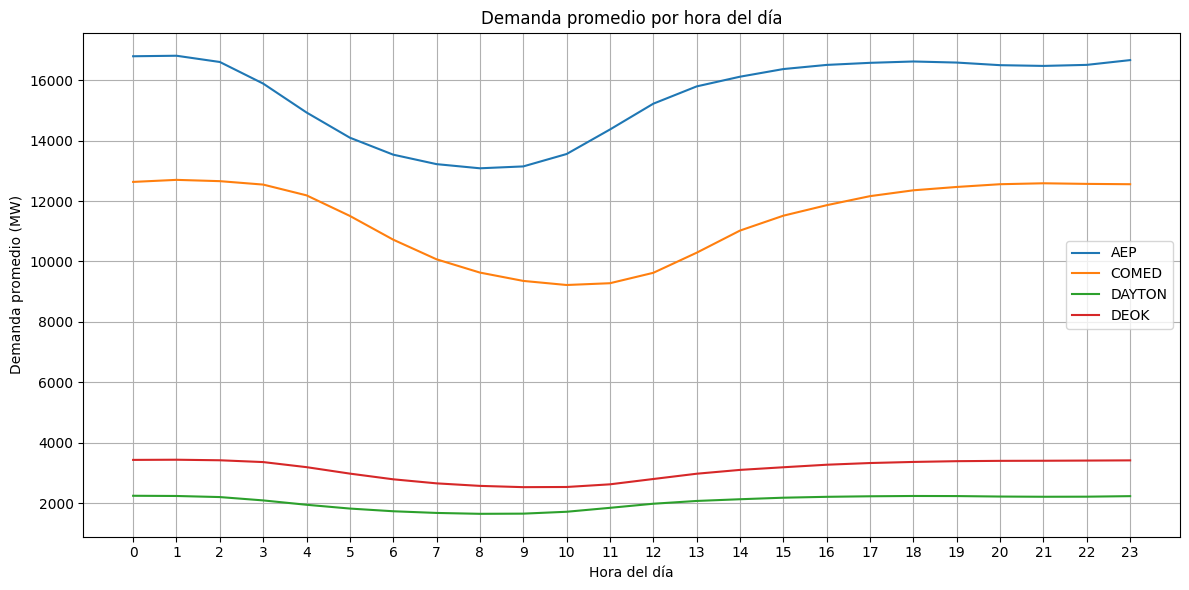

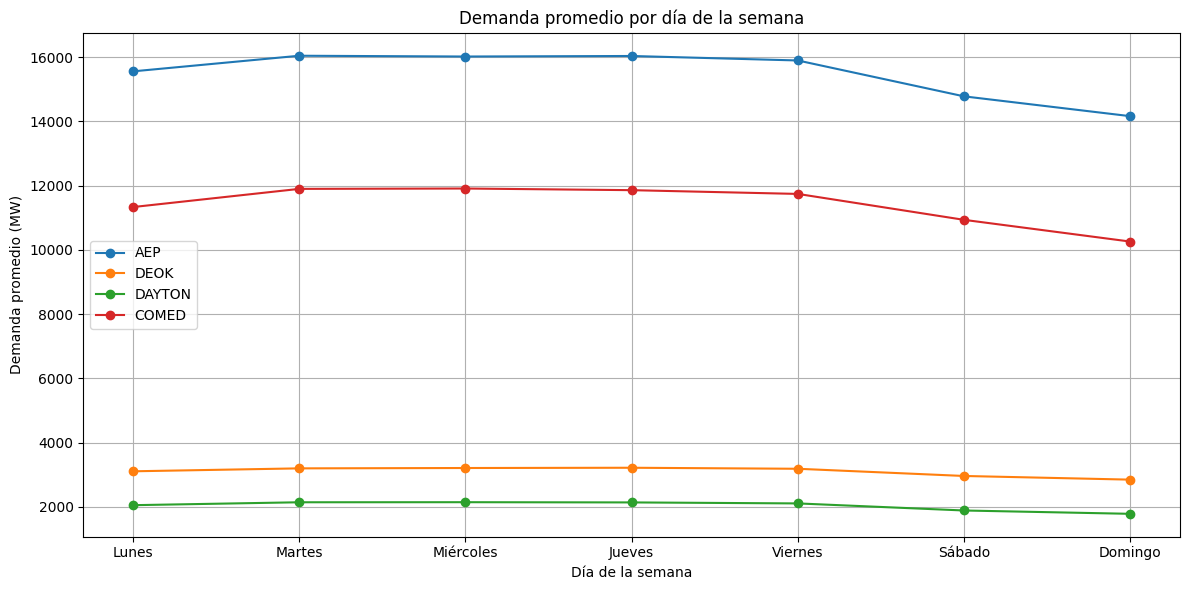

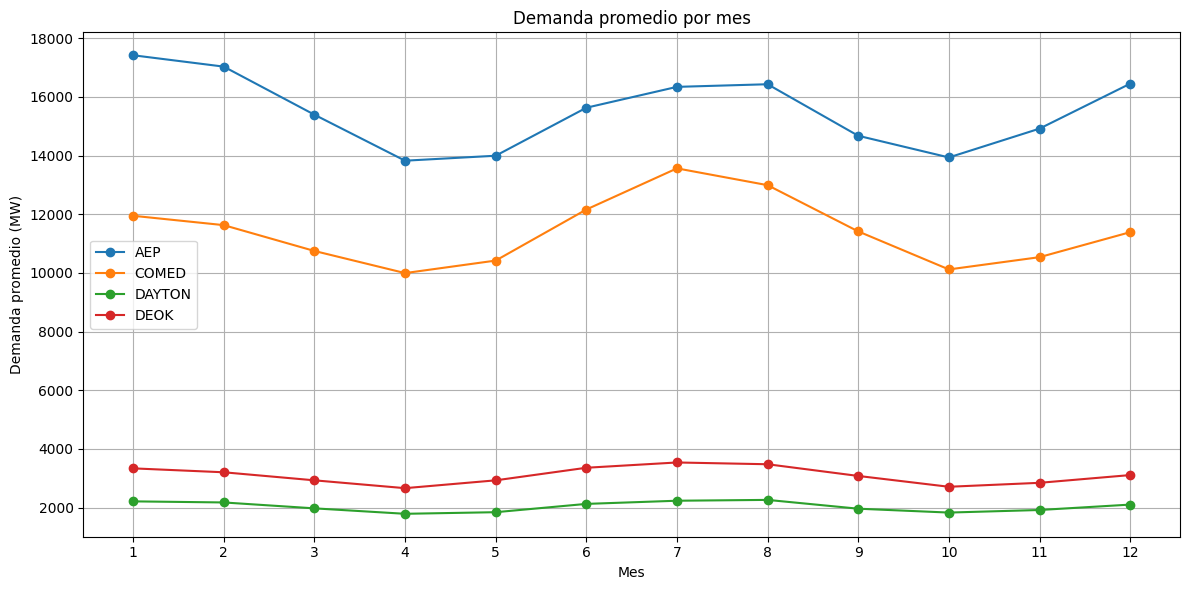



Demanda promedio: dias laborales vs fin de semana
   Region       Tipo_Dia    Demanda_MW
0     AEP    Día laboral  15910.544340
1     AEP  Fin de semana  14471.379403
2   COMED    Día laboral  11749.093028
3   COMED  Fin de semana  10597.548723
4  DAYTON    Día laboral   2118.368656
5  DAYTON  Fin de semana   1836.443440
6    DEOK    Día laboral   3184.743784
7    DEOK  Fin de semana   2905.642289


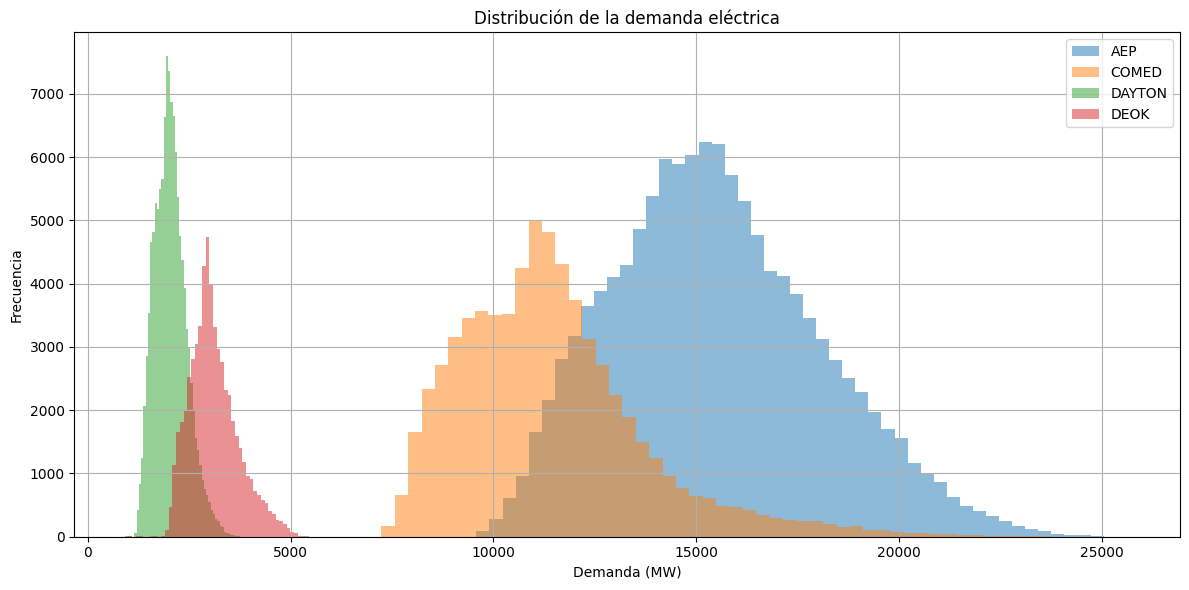

In [25]:
#Proceder con el EDA visual
import matplotlib.pyplot as plt

# Demanda promedio por hora
demanda_hora = (
    df_eda
    .groupby(["Region", "Hora"])["Demanda_MW"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(12, 6))
for region in demanda_hora["Region"].unique():

    datos_region = demanda_hora[
        demanda_hora["Region"] == region
    ]

    plt.plot(
        datos_region["Hora"],
        datos_region["Demanda_MW"],
        label=region
    )

plt.title(
    "Demanda promedio por hora del día"
)

plt.xlabel(
    "Hora del día"
)

plt.ylabel(
    "Demanda promedio (MW)"
)

plt.xticks(
    range(0, 24)
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# Demanda promedio por dia de la semana
demanda_dia = (
    df_eda
    .groupby(
        ["Region", "Día_Semana", "Nombre_Día"]
    )["Demanda_MW"]
    .mean()
    .reset_index()
)


orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

demanda_dia["Nombre_Día"] = pd.Categorical(
    demanda_dia["Nombre_Día"],
    categories=orden_dias,
    ordered=True
)


demanda_dia = demanda_dia.sort_values(
    "Nombre_Día"
)


plt.figure(figsize=(12, 6))

for region in demanda_dia["Region"].unique():

    datos_region = demanda_dia[
        demanda_dia["Region"] == region
    ]

    plt.plot(
        datos_region["Nombre_Día"],
        datos_region["Demanda_MW"],
        marker="o",
        label=region
    )

plt.title(
    "Demanda promedio por día de la semana"
)

plt.xlabel(
    "Día de la semana"
)

plt.ylabel(
    "Demanda promedio (MW)"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# Demanda promedio x mes
demanda_mes = (
    df_eda
    .groupby(
        ["Region", "Mes"]
    )["Demanda_MW"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(12, 6))

for region in demanda_mes["Region"].unique():

    datos_region = demanda_mes[
        demanda_mes["Region"] == region
    ]

    plt.plot(
        datos_region["Mes"],
        datos_region["Demanda_MW"],
        marker="o",
        label=region
    )

plt.title(
    "Demanda promedio por mes"
)

plt.xlabel(
    "Mes"
)

plt.ylabel(
    "Demanda promedio (MW)"
)

plt.xticks(
    range(1, 13)
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# Demanda fin de semana vs dias laborales
demanda_fin_semana = (
    df_eda
    .groupby(
        ["Region", "Fin_de_Semana"]
    )["Demanda_MW"]
    .mean()
    .reset_index()
)


demanda_fin_semana[
    "Tipo_Dia"
] = demanda_fin_semana[
    "Fin_de_Semana"
].map(
    {
        False: "Día laboral",
        True: "Fin de semana"
    }
)


print("\n")
print("=" * 80)
print("Demanda promedio: dias laborales vs fin de semana")
print("=" * 80)

print(
    demanda_fin_semana[
        [
            "Region",
            "Tipo_Dia",
            "Demanda_MW"
        ]
    ]
)


# Distribucion de la demanda
plt.figure(figsize=(12, 6))

for region in df_eda["Region"].unique():

    datos_region = df_eda[
        df_eda["Region"] == region
    ]

    plt.hist(
        datos_region["Demanda_MW"],
        bins=50,
        alpha=0.5,
        label=region
    )

plt.title(
    "Distribución de la demanda eléctrica"
)

plt.xlabel(
    "Demanda (MW)"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()

In [ ]:
#La demanda aumenta en ciertos meses, debido posiblemente a temperaturas extremas
#Conseguir temperaturas promedio/maxima/minima de las regiones y comprobar si existe corrrelacion
#La actiidad laboral y comercial influye en el consumo, comparar por hora dia lbaroal vs fin de semana y observar si la diferencia se concentra en horarios laborales